# a03 Example - Bayesian Optimization using AX Client

# Install External Libraries for Optimizer Implementation

In [ ]:
!python -m pip install ax-platform

# Imports

In [1]:
import pyscan as ps
import numpy as np
import matplotlib.pyplot as plt

from ax.api.client import Client
from ax.api.configs import RangeParameterConfig

## Setup devices

In [2]:
devices = ps.ItemAttribute()

devices.v1 = ps.TestVoltage() # Device 1
devices.v2 = ps.TestVoltage() # Device 2

## Define a measure function

In [3]:
def voltage_response(v1, v2):
    """
    Paraboloid function to optimize.
    """
    return (v1 - 4)**2 + (v2 - 6)**2

def get_voltage_data(expt):
    """
    Reads the voltage from v1 and v2. Also adds a calculated voltage response to optimize.
    """

    runinfo = expt.runinfo
    devices = expt.devices

    d = ps.ItemAttribute()

    d.v1_readout = devices.v1.voltage
    d.v2_readout = devices.v2.voltage

    d.vf = voltage_response(d.v1_readout, d.v2_readout)

    return d

# Define live plot

In [4]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, ax, cb0, cb1
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                cmap='viridis')
    ax.set_box_aspect(1)
    if cb0 is None and cb1 is None:
        cb0 = fig.colorbar(scatter, label="optimizer step")
        cb1 = fig.colorbar(pcm, label="voltage response")
    else:
        cb0.update_normal(scatter)
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

# Define runinfo

In [5]:
runinfo = ps.RunInfo()
runinfo.measure_function = get_voltage_data

# Implement `AbstractOptimizeScan` with `AXOptimizeScan`

In [6]:
class AXOptimizeScan(ps.AbstractOptimizeScan):
    """
    AX API
    """


    def __init__(self, initialization_dict, prop, optimizer_inputs, sample_function_output,
                 bounds_list,
                 dt=0., n_max=100, global_improvement_threshold=1e-1,
                 extremum='min'):
        
        super().__init__(initialization_dict, prop, optimizer_inputs, sample_function_output,
                         dt=dt, n_max=n_max)

        self.last_optim_idx = n_max - 1 # stop optimizing on second-to-last index so that last index is best discovered value
        self.gi_thresh = global_improvement_threshold 
        self.proposed_trial_index = None
    
        parameters = [
            RangeParameterConfig(name=self.opt_in[i], parameter_type="float", bounds=bounds_list[i])
            for i in range(len(self.opt_in))
        ]
        self.client = Client()
        self.client.configure_experiment(parameters=parameters)
        match extremum:
            case 'max':
                self.objective = f"{self.sample_f_out}"
            case 'min':
                self.objective = f"-{self.sample_f_out}"
            case _:
                raise ValueError('Extremum must be max or min')
        self.client.configure_optimization(objective=self.objective)


    def step_optimizer(self, index, experiment):

            if index == 1: # load initial point into AX measurement history
                parameters = {
                    measurement: experiment.__dict__[measurement][0]
                    for measurement in self.opt_in
                }
                prev_trial_index = self.client.attach_trial(parameters=parameters)
                f_out = experiment.__dict__[self.sample_f_out][index - 1]
                raw_data = {self.sample_f_out: f_out}
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)
            else: # load last proposed trial results into AX measurement history
                best_parameters, best_prediction, best_index, best_name = self.client.get_best_parameterization(use_model_predictions=False)
                f_out = experiment.__dict__[self.sample_f_out][index - 1]
                raw_data = {self.sample_f_out: f_out}
                prev_trial_index = self.proposed_trial_index
                self.client.complete_trial(trial_index=prev_trial_index, raw_data=raw_data)

                f_out_best = best_prediction[self.sample_f_out][0] # get mean from (mean, sem) of output
                if not (index < self.last_optim_idx) or not (abs(f_out - f_out_best) > self.gi_thresh):
                    f_in_next = [
                            best_parameters[measurement]
                            for measurement in self.opt_in
                        ]
                    self.running = False
                    print(f"best param: {best_parameters}")
                    return f_in_next

            trials = self.client.get_next_trials(max_trials=1) # only 1 trial
            for trial_index, parameters in trials.items(): # only 1 item
                f_in_next = [
                    parameters[measurement]
                    for measurement in self.opt_in
                ]
                self.proposed_trial_index = trial_index

            return f_in_next


# Instantiate OptimizeScan

In [7]:
runinfo.scan0 = AXOptimizeScan({'v1': 2., 'v2': 1.}, 'voltage', ('v1_readout', 'v2_readout'), 'vf',
                               ((0., 10.), (0., 10.)),
                               dt=1., n_max=20)

# Run Experiments

In [ ]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

[INFO 12-01 12:28:11] ax.api.client: Trial 0 marked COMPLETED.
[INFO 12-01 12:28:11] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(node_name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(node_name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 12-01 12:28:11] ax.api.client: Generated new trial 1 with parameters {'v1_readout': 5.0, 'v2_readout': 5.0} using GenerationNode CenterOfSearchSpace.
[INFO 12-01 12:28:12] ax.api.client: Trial 1 marked COMPLETED.
[INFO 12-01 12:28:12] ax.api.client: Generated new trial 2 with parameters {'v1_readout': 8.859677, 'v2_readout': 7.54799} using GenerationNode Sobol.
[INFO 12-01 12:28:13] ax.api.client: 

best param: {'v1_readout': 3.9268025377457185, 'v2_readout': 5.970170455400635}
Stopping Experiment


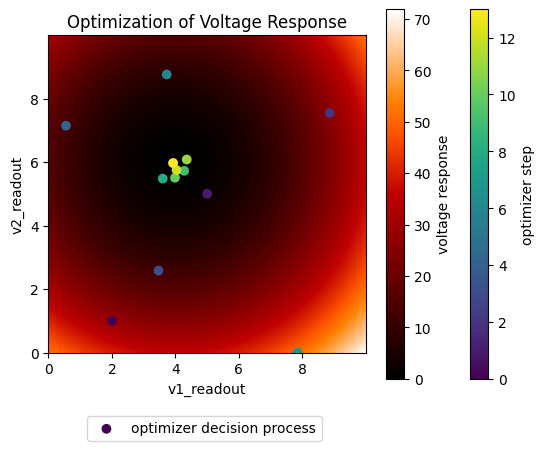

In [9]:
fig, ax = plt.subplots()
cb0 = cb1 = None
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [10]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x1be983df6e0>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x1be981f5730>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 47980)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13.]),
 'v1_readout': array([2.        , 5.        , 8.85967731, 3.46776747, 0.55136872,
        3.92680254, 3.72589636, 7.84564066, 3.60104746, 4.27653235,
        3.9866888 , 4.35705467, 4.03577299, 3.92680254]),
 'v2_readout': array([1.        , 5.        , 7.54799008, 2.58194367, 7.14622595,
        5.97017046, 8.75988291, 0.        , 5.47891713, 5.72508714,
        5.50697224, 6.08103647, 5.74719098, 5.97017046]),
 'vf': array([2.90000000e+01, 2.00000000e+00, 2.60127369e+01, 1.19663805e+01,
        1.32068916e+01, 6.24767021e-03, 7.69208650e+00, 5.07889521e+01,
        4.30690485e-01, 1.52047217e-01, 2.43253557e-01, 1.34054945e-01,
        6.51921094e-02, 6.24767021e-03])}

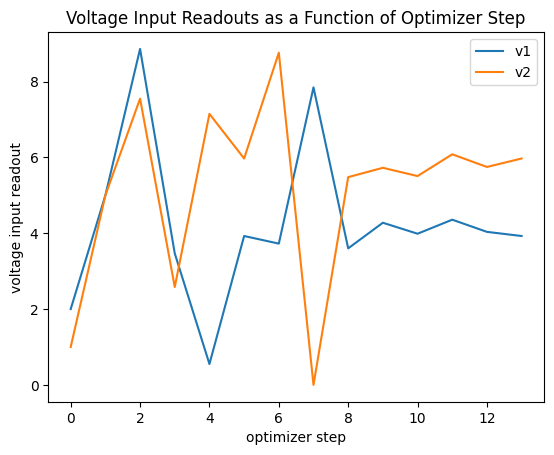

In [11]:
plt.plot(list(zip(expt.v1_readout, expt.v2_readout)))
plt.legend(['v1', 'v2'])
plt.xlabel("optimizer step")
plt.ylabel("voltage input readout")
plt.title("Voltage Input Readouts as a Function of Optimizer Step");

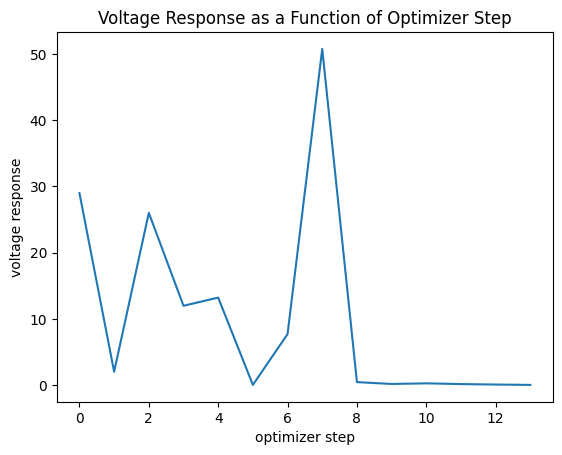

In [12]:
plt.plot(expt.vf)
plt.xlabel("optimizer step")
plt.ylabel("voltage response")
plt.title("Voltage Response as a Function of Optimizer Step");

In [13]:
def plot_optim_pcm():
    fig, ax = plt.subplots()
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    pcm = ax.pcolormesh(x, y, z, cmap='gist_heat')
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, c=range(len(expt.v1_readout)),
                         cmap='viridis')
    ax.set_box_aspect(1)
    fig.colorbar(scatter, label="optimizer step")
    fig.colorbar(pcm, label="voltage response")
    ax.legend(["optimizer decision process",], loc='lower left', bbox_to_anchor=(.1, -.3))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_title("Optimization of Voltage Response")

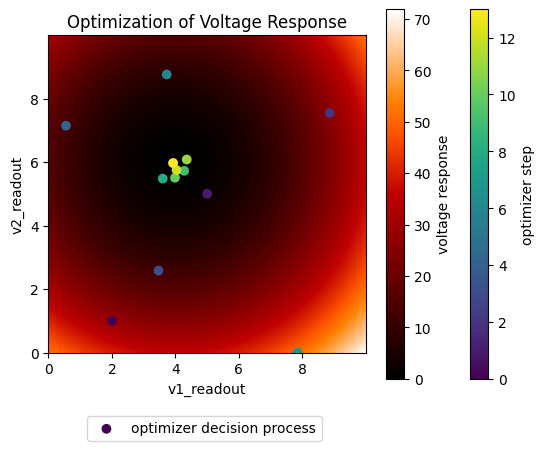

In [14]:
plot_optim_pcm()

In [15]:
def plot_optim_3d(elevation, azimuth):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x, y = np.mgrid[0:10:.01, 0:10:.01]
    z = np.array(voltage_response(np.ravel(x), np.ravel(y)))
    z = z.reshape(x.shape)
    ax.plot_surface(x, y, z, color='C1', alpha=.5)
    scatter = ax.scatter(expt.v1_readout, expt.v2_readout, expt.vf, c=range(len(expt.v1_readout)))
    ax.view_init(elev=elevation, azim=azimuth)
    fig.colorbar(scatter, label="optimizer step", pad=.1)
    ax.legend(["voltage response function", "optimizer decision process",], loc='lower left', bbox_to_anchor=(.2, -.2))
    ax.set_xlabel("v1_readout")
    ax.set_ylabel("v2_readout")
    ax.set_zlabel("voltage response")
    ax.set_title("Optimization of Voltage Response")

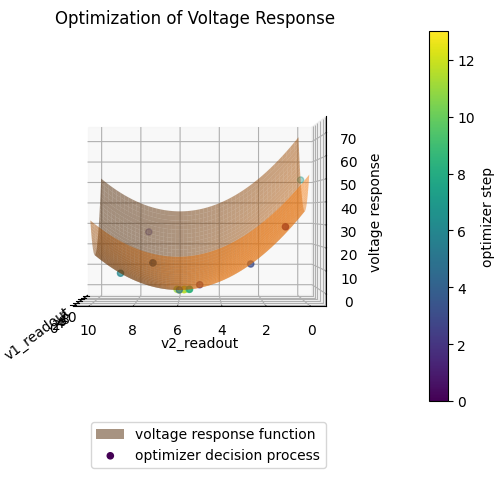

In [16]:
plot_optim_3d(0, 180)

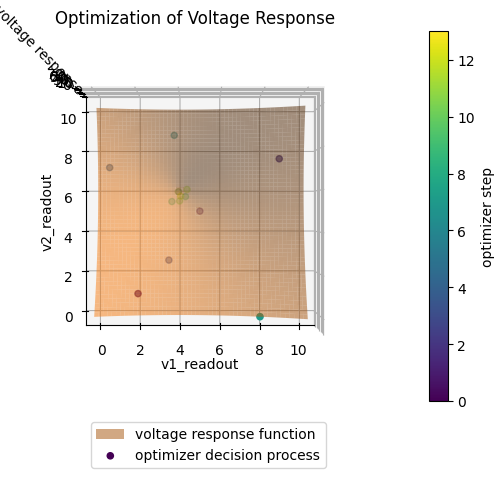

In [17]:
plot_optim_3d(90, 270)

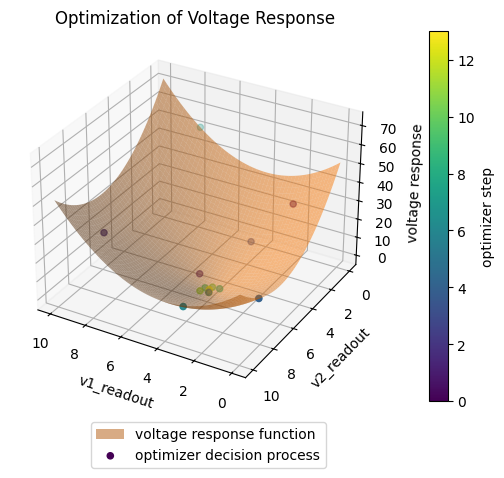

In [18]:
plot_optim_3d(30, 120)